# Case study 1: How does a bike-share navigate speedy success? 

## Executive Summary
This analysis of 5.68 million Cyclistic bike-share trips reveals that casual riders and annual members use the service in fundamentally different ways. Casual riders take **59% longer trips** (19.6 vs. 12.3 minutes), concentrated on weekends and summer afternoons at recreational hotspots like Navy Pier and Millennium Park, while members show sharp weekday commuting peaks at **8 AM and 5 PM** near business districts. Despite the duration gap, both groups travel nearly identical distances (~2.2 km), and casual riders are **2.8x more likely** to take loop trips — confirming leisure, not transportation, as their primary use case. Casual demand also surges **13-fold** from January to August, compared to a steadier 4-fold rise for members, pointing to a clear seasonal window for conversion. These findings suggest Cyclistic's strongest opportunity lies in weekend- and summer-focused membership campaigns at high-traffic leisure locations, positioned around cost savings and flexibility rather than commuting value.

Author: Daisy Nguyen | Tools: BigQuery, Python (Pandas, Matplotlib/Seaborn) | Date: 06 Jul 2026

Tableau: https://public.tableau.com/views/HowCasualRidersandMembersdifference/Dashboard2?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

⚠️ Reminder:  
This notebook contains sample BigQuery code.  
Queries cannot be run directly here, as they require access to a linked Google Cloud project.  
Please view the code and results as examples only.

This case study belongs to the Google Data Analytics Capstone: Complete a Case Study of Google Data Analytics Professional Certificate.

In this Project, I need to analyze historical bicycle trip data in order to identify trends. Understanding how casual riders behave differently from riders with paid memberships is important. 

This analysis will help executives to make decisions about marketing programs and strategies to convert casual riders to riders with annual memberships.

Refer to 
[> Case Study 1: How Does a Bike-Share Navigate Speedy Success?](https://www.coursera.org/learn/google-data-analytics-capstone/supplement/7PGIT/case-study-1-how-does-a-bike-share-navigate-speedy-success)

# Business analysis

## 1. The problem
The Board of Director of Cyclistic, a bike-share company in Chicago believes that expanding the number of annual members is essential to ensure the company's long-term success. To achieve this, they plan to launch a marketing campaign aimed at converting the casual riders into annual members. However, the company lacks insights into how usage patterns differ between the two groups, leaving the campaign without a data-driven foundation.

This is a knowledge gap between what the company knows and what it needs to design an effective strategy.

## 2. Key stakeholders
* Cyclistic marketing analytics team: A team of data analysts who are responsible for 
collecting, analyzing, and reporting data that helps guide Cyclistic marketing strategy.
* Lily Moreno: The director of marketing and your manager. Moreno is responsible for 
the development of campaigns and initiatives to promote the bike-share program.
* Cyclistic executive team: The notoriously detail-oriented executive team wil decide 
whether to approve the recommended marketing program. 

## 3. Business Task
Analyzing Cyclistic’s historical trip data to uncover the differences in the usage between casual riders and annual members, providing insights that will guide a marketing strategy to drive casual riders toward annual membership.

# Data description

Here is the [dataset](https://www.kaggle.com/datasets/duyennguyenthixuan/cyclistics-historical-trip-data)
This is the 12 months of Cyclistic trip data (from 06/2025 to 05/2026). The data has been made available by Motivate International Inc. under this license.) Each month is a separate CSV file inside its own zip, so 12 months means 12 files that need to be combined. Each row is one individual bike trip, with columns typically including ride ID, rideable type, start/end timestamps, start/end station name and ID, start/end latitude and longitude, and rider type (member vs. casual).

This data is ROCCC:
* Reliable — collected directly by the bike-share system itself, not self-reported.
* Original — first-party data, not scraped or aggregated from a third party.
* Comprehensive — covers every trip taken, not a sample.
* Current — released on a rolling monthly basis. (still being updated)
* Cited — provided according to the Divvy Data License Agreement, with clear attribution to Motivate International Inc./Divvy.

Licensing, privacy, security, accessibility
The data is public and free to use under that license, but it's already been stripped of personally identifiable information — no names, no payment info, no ability to link a rider across multiple trips.

# Data’s prepare and process 
## Cleaning Data Steps

**1. Tools**
In this project, multiple tools were employed to ensure efficient handling, transformation, and analysis of large-scale datasets.
*    MySQL was first utilized to consolidate twelve separate datasets into a single unified table. This step was critical for verifying data integrity after merging, as MySQL’s relational structure and query capabilities provided a stable environment to check consistency across millions of records. By performing the initial integration within a database engine, the project ensured that the combined dataset was accurate, coherent, and ready for subsequent analysis.
  
* Following the consolidation, Google BigQuery was adopted as the primary platform for querying and computation. BigQuery’s cloud‑based, distributed architecture is optimized for large‑scale analytics, enabling complex queries to be executed quickly and reliably on datasets that exceeded the practical limits of local database servers. This choice addressed the scalability challenges encountered with MySQL and ensured that analytical operations could be performed without interruption.

* Finally, Python (Pandas) was employed for the downstream stages of analysis. Once BigQuery had reduced and structured the dataset into a manageable size, Pandas provided the flexibility needed for exploratory analysis, data transformation, and visualization. Its rich ecosystem of libraries allowed for ad hoc exploration and the creation of presentation‑ready outputs, complementing the strengths of BigQuery by enabling detailed insights and clear communication of results.

**2. Prepare and Diagnose**
* Download the trip data for the last 12 months, then upload on Kaggle.
> Sequentially check the data of each file and review the statistics for each column (In column tab) within those files and all files    * Title of colum
> > Data type and data format
> > Missing data
> > ride_id: unique or not; rideable_type: only 2 options available; member_casual: : only 2 options available

* Sort the `started_at` and `ended_at` columns (ascending and descending) to verify that the recorded times fall within the designated month.

* MySQL: Create an empty table and import data 12 months, check data integrity. Then export combined file in .cvs

In [ ]:
#Create a `trips` table to store data from 12 CSV files.
CREATE DATABASE cyclistic_trips;
USE cyclistic_trips;

CREATE TABLE trips (
    ride_id VARCHAR(50),
    rideable_type VARCHAR(20),
    started_at DATETIME(3),
    ended_at DATETIME(3),
    start_station_name VARCHAR(100),
    start_station_id VARCHAR(50),
    end_station_name VARCHAR(100),
    end_station_id VARCHAR(50),
    start_lat DECIMAL(10,8),
    start_lng DECIMAL(11,8),
    end_lat DECIMAL(10,8),
    end_lng DECIMAL(11,8),
    member_c VARCHAR(20)
);

#Import data from 12 CSV files into `trips` table. Repeat for each file
LOAD DATA LOCAL INFILE 'C:/Users/HP/Downloads/tripdata/202601tripdata.csv'
INTO TABLE trips
FIELDS TERMINATED BY ','
ENCLOSED BY '"'
LINES TERMINATED BY '\r\n'
IGNORE 1 ROWS
(ride_id, rideable_type, started_at, ended_at, start_station_name, start_station_id,
 end_station_name, end_station_id, start_lat, start_lng, end_lat, end_lng, member_c);

.....


* Verify data integrity after merging into a single table by checking whether the final number of rows equals the total number of rows from the 12 files.

In [ ]:
SELECT count(*)
FROM trips

Result must be: 5848703

* Upload file on GG console Cloud and import file into the project on BigQuery. Check Data integrity.
* * Duplicated data
  * Check for unusual trip duration
  * Check if the classification value is abnormal
  * Check if Station ID and station name pairs are consistent
  * % null data

In [ ]:
#Check for duplicate ride_id
SELECT ride_id, count(*) as cnt
FROM `data-analyst-501608.cyclistic_analysis.trips_combined`
GROUP BY ride_id
HAVING cnt > 1

#Check for unusual trip duration
SELECT
  countif(timestamp_diff(ended_at, started_at,SECOND)<=0) AS less_than_0,
  countif(timestamp_diff(ended_at, started_at,SECOND)<60) AS too_short,
  countif(timestamp_diff(ended_at, started_at,SECOND)>86400) AS too_long
FROM `data-analyst-501608.cyclistic_analysis.trips_combined` 

#Check if the rideable_type,member_casual is abnormal
SELECT rideable_type,member_casual 
FROM `data-analyst-501608.cyclistic_analysis.trips_combined`
GROUP BY rideable_type,member_casual

#Check the number of station names associated with more than one ID and the number of IDs associated with more than one name.
WITH all_stations AS (
  SELECT start_station_name AS station_name, start_station_id AS station_id
  FROM `data-analyst-501608.cyclistic_analysis.trips_combined`
  WHERE start_station_name IS NOT NULL AND start_station_id IS NOT NULL
  UNION ALL
  SELECT end_station_name AS station_name, end_station_id AS station_id
  FROM `data-analyst-501608.cyclistic_analysis.trips_combined`
  WHERE end_station_name IS NOT NULL AND end_station_id IS NOT NULL
)
SELECT
  (SELECT COUNT(*) 
  FROM 
    (SELECT station_name 
    FROM all_stations 
    GROUP BY station_name 
    HAVING COUNT(DISTINCT station_id) > 1)) AS names_with_multiple_ids,
    (SELECT COUNT(*) 
    FROM 
    (SELECT station_id 
    FROM all_stations 
    GROUP BY station_id 
    HAVING COUNT(DISTINCT station_name) > 1)) AS ids_with_multiple_names

#Check what % of total trips are touched by these ambiguous stations
WITH all_stations AS (
  SELECT start_station_name AS station_name, start_station_id AS station_id
  FROM `data-analyst-501608.cyclistic_analysis.trips_combined`
  WHERE start_station_name IS NOT NULL AND start_station_id IS NOT NULL
  UNION ALL
  SELECT end_station_name, end_station_id
  FROM `data-analyst-501608.cyclistic_analysis.trips_combined`
  WHERE end_station_name IS NOT NULL AND end_station_id IS NOT NULL
),
ambiguous_names AS (
  SELECT station_name FROM all_stations GROUP BY station_name HAVING COUNT(DISTINCT station_id) > 1
),
ambiguous_ids AS (
  SELECT station_id FROM all_stations GROUP BY station_id HAVING COUNT(DISTINCT station_name) > 1
)
SELECT
  COUNT(*) AS total_rows,
  COUNTIF(start_station_name IN (SELECT station_name FROM ambiguous_names)
       OR end_station_name IN (SELECT station_name FROM ambiguous_names)) AS rows_affected_by_ambiguous_name,
  COUNTIF(start_station_id IN (SELECT station_id FROM ambiguous_ids)
       OR end_station_id IN (SELECT station_id FROM ambiguous_ids)) AS rows_affected_by_ambiguous_id
FROM `data-analyst-501608.cyclistic_analysis.trips_combined`

#The number of row have station NULL record
SELECT Count(*)
FROM `data-analyst-501608.cyclistic_analysis.trips_combined`
WHERE start_station_name IS NULL OR start_station_id IS NULL OR end_station_name IS NULL OR end_station_id IS NULL

## Data Integrity (First Look)


1. Completeness
* All 12 monthly zip files downloaded successfully (correct row count vs. source file size)
* Each CSV unzips without corruption or truncation
* No missing months in the 12-month range
* *1970294/5848703 rows have a NULL station name or id (33.68%)*
2. Schema Consistency
* Column names identical across all 12 files
* Column order and count match across files before merging
* Data types consistent per column across months
3. Uniqueness
* *35 ride_id is duplicated in combined file*
4. Validity / Conformity
* started_at and ended_at are valid, parseable datetime values (no text, blanks, or malformed dates)
* *1808 (0.03%) records have ended_at sooner than started_at (negative-duration rides)*
* *161352 (2.7%) trips were too short (< 60 seconds)*
* *5843 (0.09%) trips were too long (> 24 hours)*
* member_casual contains only the two expected values ("member", "casual") — no typos, blanks, or third categories
* rideable_type contains only two expected values ("classic_bike", "electric_bike")
* *70 station names with multiple ids and 55 station ids have multiple name*
* *364566 (~6.23%) rows affected by ambiguous station names and 727865 (~12.44%) rows affected by ambiguous station ids*

5. Timeliness

 Confirm the 12 months selected are the most recent complete months available at analysis time
 Note the exact date range covered in your documentation (June 2025–May 2026") so findings aren't assumed to reflect data outside that window

6. Bias & Credibility (ROCCC re-check after cleaning)

 Confirm cleaning steps didn't disproportionately remove one rider type over another (e.g., check % of casual vs. member rows dropped due to nulls — if casual riders are dropped more heavily, your conclusions could be skewed)
 Document any rows/columns excluded and why, so the executive team can evaluate whether the cleaned dataset still fairly represents both rider types

7. Documentation & Reproducibility

 Every cleaning transformation is scripted (not manual spreadsheet edits) so it's reproducible
 A data cleaning log is kept: what was removed, how many rows/columns, and the reasoning
 Before/after row counts recorded at each cleaning step, so total data loss is transparent and justifiable to stakeholders
  

**3. Clean Data**



In my data cleaning work, I categorized issues into two types: 
* irrecoverable errors that required dropping rows
* recoverable inconsistencies that needed resolution.

Irrecoverable errors included duplicate ride IDs (caused by UNION ALL merges), negative durations (timestamp corruption), trips shorter than 60 seconds (false starts or test docks), and trips longer than 24 hours (likely lost or undocked bikes). These cases represented genuine data corruption and were removed to preserve analytical integrity.

On the other hand, station name-to-ID mismatches were not true errors—the trips were valid, but the station labels were inconsistent. Because this affected a significant portion of the dataset, I resolved these cases using a coordinate-distance lookup table rather than discarding them. This approach ensured that the dataset remained accurate while retaining as much valuable information as possible.

In [ ]:
#Create cleaned table that removed irrecoverable errors
CREATE OR REPLACE TABLE `data-analyst-501608.cyclistic_analysis.trips_cleaned` AS
WITH deduplicated AS (
  SELECT *
  FROM (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY ride_id ORDER BY started_at) AS rn
    FROM `data-analyst-501608.cyclistic_analysis.trips_combined`
  )
  WHERE rn = 1
)
SELECT *
FROM deduplicated
WHERE timestamp_diff(ended_at, started_at, SECOND) > 60              -- remove trips shorter than 60 seconds
  AND timestamp_diff(ended_at, started_at, SECOND) < 86400           -- remove trips longer than 24 hours (24*3600)

Result: 'trips_cleaned' table with 5680140 records

For records with ambiguous station IDs or names, I relied on latitude and longitude as the definitive reference point instead of trying to correct the station_name or station_id, since both fields were unreliable.
I treated the rounded coordinates as the true station identifier, then assigned each coordinate a “representative” name and ID by selecting the most frequently occurring value. Rounding the coordinates to four decimal places (about 111 meters of precision) naturally groups stations that are very close together while keeping distinct locations separate. This approach avoids arbitrary thresholds and leverages the inherent accuracy of GPS data to resolve inconsistencies.

In [ ]:
#Create a station lookup table based on coordinates.
CREATE OR REPLACE TABLE `data-analyst-501608.cyclistic_analysis.station_lookup` AS
WITH combined AS (
  SELECT TRIM(start_station_name) AS station_name, start_station_id AS station_id,
         FORMAT('%.3f', start_lat) AS lat_key, FORMAT('%.3f', start_lng) AS lng_key
  FROM `data-analyst-501608.cyclistic_analysis.trips_cleaned`
  WHERE start_station_name IS NOT NULL AND start_lat IS NOT NULL
  UNION ALL
  SELECT TRIM(end_station_name), end_station_id,
         FORMAT('%.3f', end_lat), FORMAT('%.3f', end_lng)
  FROM `data-analyst-501608.cyclistic_analysis.trips_cleaned`
  WHERE end_station_name IS NOT NULL AND end_lat IS NOT NULL
),
best_name AS (
  SELECT lat_key, lng_key, station_name
  FROM combined
  GROUP BY lat_key, lng_key, station_name
  QUALIFY ROW_NUMBER() OVER (PARTITION BY lat_key, lng_key ORDER BY COUNT(*) DESC, station_name ASC) = 1
),
best_id AS (
  SELECT lat_key, lng_key, station_id
  FROM combined
  GROUP BY lat_key, lng_key, station_id
  QUALIFY ROW_NUMBER() OVER (PARTITION BY lat_key, lng_key ORDER BY COUNT(*) DESC, station_id ASC) = 1
)
SELECT
  bn.lat_key, bn.lng_key,
  bn.station_name AS canonical_station_name,
  bi.station_id AS canonical_station_id
FROM best_name bn
JOIN best_id bi USING (lat_key, lng_key);

Update the `station_name` and `station_id` (started and ended stations) for the relevant records, matching them to the names and IDs found in the "station_id_with_multiple_names" and "station_name_with_multiple_ids" tables. Do not modify records that are null or already contain valid names and station IDs, in order to minimize data changes.

In [ ]:
CREATE OR REPLACE TABLE `data-analyst-501608.cyclistic_analysis.trips_final` AS
WITH flagged AS (
  SELECT
    t.*,
    (
      (t.start_station_name IS NOT NULL AND t.start_station_name IN (
        SELECT station_name FROM `data-analyst-501608.cyclistic_analysis.station_name_with_multiple_id`
      ))
      OR
      (t.start_station_id IS NOT NULL AND t.start_station_id IN (
        SELECT station_id FROM `data-analyst-501608.cyclistic_analysis.station_id_with_multiple_name`
      ))
    ) AS start_is_ambiguous,
    (
      (t.end_station_name IS NOT NULL AND t.end_station_name IN (
        SELECT station_name FROM `data-analyst-501608.cyclistic_analysis.station_name_with_multiple_id`
      ))
      OR
      (t.end_station_id IS NOT NULL AND t.end_station_id IN (
        SELECT station_id FROM `data-analyst-501608.cyclistic_analysis.station_id_with_multiple_name`
      ))
    ) AS end_is_ambiguous
  FROM `data-analyst-501608.cyclistic_analysis.trips_cleaned` t
)
SELECT
  f.* EXCEPT(start_station_name, start_station_id, end_station_name, end_station_id, start_is_ambiguous, end_is_ambiguous),

  CASE WHEN f.start_is_ambiguous THEN sl_start.canonical_station_name ELSE f.start_station_name END AS start_station_name,
  CASE WHEN f.start_is_ambiguous THEN sl_start.canonical_station_id   ELSE f.start_station_id   END AS start_station_id,
  CASE WHEN f.end_is_ambiguous   THEN sl_end.canonical_station_name   ELSE f.end_station_name     END AS end_station_name,
  CASE WHEN f.end_is_ambiguous   THEN sl_end.canonical_station_id     ELSE f.end_station_id       END AS end_station_id

FROM flagged f
LEFT JOIN `data-analyst-501608.cyclistic_analysis.station_lookup` sl_start
  ON f.start_is_ambiguous
 AND FORMAT('%.3f', f.start_lat) = sl_start.lat_key
 AND FORMAT('%.3f', f.start_lng) = sl_start.lng_key
LEFT JOIN `data-analyst-501608.cyclistic_analysis.station_lookup` sl_end
  ON f.end_is_ambiguous
 AND FORMAT('%.3f', f.end_lat) = sl_end.lat_key
 AND FORMAT('%.3f', f.end_lng) = sl_end.lng_key

# # Check after creating the final table

In [ ]:
#Count exactly how many rows were actually changed.
SELECT
  COUNTIF(c.start_station_name IS DISTINCT FROM f.start_station_name) AS start_name_changed,
  COUNTIF(c.start_station_id   IS DISTINCT FROM f.start_station_id)   AS start_id_changed,
  COUNTIF(c.end_station_name   IS DISTINCT FROM f.end_station_name)   AS end_name_changed,
  COUNTIF(c.end_station_id     IS DISTINCT FROM f.end_station_id)     AS end_id_changed
FROM `data-analyst-501608.cyclistic_analysis.trips_cleaned` c
JOIN `data-analyst-501608.cyclistic_analysis.trips_final` f USING (ride_id)

#Confirm that no null rows were accessed.
SELECT
  (SELECT COUNTIF(start_station_name IS NULL) FROM `data-analyst-501608.cyclistic_analysis.trips_cleaned`) AS null_before,
  (SELECT COUNTIF(start_station_name IS NULL) FROM `data-analyst-501608.cyclistic_analysis.trips_final`) AS null_after

#Confirm total number of lines remains unchanged
SELECT
  (SELECT COUNT(*) FROM `data-analyst-501608.cyclistic_analysis.trips_cleaned`) AS rows_before,
  (SELECT COUNT(*) FROM `data-analyst-501608.cyclistic_analysis.trips_final`) AS rows_after

Result: trips_final — approximately 5.68 million clean, deduplicated trip records with standardized station identifiers, ready for the Analyze phase.

# Analyze

With trips_final cleaned and verified, my approach to the Analyze phase follows four stages: 
1. engineer the fields needed for meaningful comparison
2. verify they're correctly formatted
3. aggregate the data into digestible summaries
4. look for behavioral patterns between the two rider groups.

**Step 1 — Feature Engineering: Create Analysis-Ready Columns**
Three derived columns are needed before any comparison is meaningful, since the raw data only contains timestamps and coordinates, not the actual behavioral metrics I'm trying to compare.
**ride_length — trip duration**
Calculated by subtracting started_at from ended_at. I'm keeping this in seconds at the SQL level for precision, and will convert to minutes only when presenting results, to avoid rounding errors compounding across aggregations.
**day_of_week — which day each ride started**
Extracted directly from started_at, formatted as a full day name for readability in charts rather than a numeric index (0–6), which would require a lookup table every time I present results.
**distance_km — straight-line distance between start and end coordinates**
distance_km is calculated using the Haversine formula, measuring straight-line distance between start/end coordinates rather than actual cycling route distance — meaning loop rides (same start/end station) will show 0km despite a non-zero ride duration.

In [ ]:
CREATE OR REPLACE TABLE `data-analyst-501608.cyclistic_analysis.trips_final` AS
SELECT 
  ride_id,
  rideable_type,started_at, ended_at, start_lat, start_lng, end_lat, end_lng, member_casual, start_station_name, start_station_id, end_station_name, end_station_id,
  TIMESTAMP_DIFF(ended_at,started_at,SECOND) as ride_length,
  EXTRACT(DAYOFWEEK FROM started_at) AS day_of_week,
  FORMAT_TIMESTAMP('%A', started_at) AS day_of_week_name,
  6371 * 2 * ASIN(
    SQRT(
      POWER(SIN(((end_lat - start_lat) * ACOS(-1) / 180) / 2), 2) +
      COS(start_lat * ACOS(-1) / 180) * COS(end_lat * ACOS(-1) / 180) *
      POWER(SIN(((end_lng - start_lng) * ACOS(-1) / 180) / 2), 2)
    )
  ) AS distance_km
FROM `data-analyst-501608.cyclistic_analysis.trips_final`

**Step 2 — Verify Formatting Before Trusting Any Result**
Before running a single comparison, I check that the new columns behave as expected — this is the same discipline I applied during the Process phase, and skipping it here would risk building an entire analysis on a silently broken column.

In [ ]:
SELECT
  MIN(ride_length) AS min_duration,
  MAX(ride_length) AS max_duration,
  MIN(distance_km) AS min_distance,
  MAX(distance_km) AS max_distance,
  COUNTIF(distance_km IS NULL) AS null_distance_rows FROM `data-analyst-501608.cyclistic_analysis.trips_final`

Results:
* min_duration: 61 (Accepted: positive (already enforced during cleaning))
* max_duration: 86398
* min_distance: 0
* *max_distance: 9824.4223145433243*
* null_distance_rows: 0

A small number of trips (n = 253) had end coordinates recorded as (0, 0) — a common GPS sentinel value indicating a failed location capture, not a real trip to the Gulf of Guinea. These trips' distance_km was set to NULL rather than dropping the row, since ride duration and other fields remained valid.

In [ ]:
#Set to NULL the distance_km which had end coordinates recorded as (0, 0)
CREATE OR REPLACE TABLE `data-analyst-501608.cyclistic_analysis.trips_final` AS
SELECT
  * EXCEPT(distance_km),
  CASE
    WHEN (start_lat = 0 AND start_lng = 0) OR (end_lat = 0 AND end_lng = 0) THEN NULL
    ELSE distance_km
  END AS distance_km
FROM `data-analyst-501608.cyclistic_analysis.trips_final`

**Step 3 — Aggregate Into Summary Tables**
Rather than repeatedly querying 5.68 million rows for every chart, I build small, purpose-built summary tables — one per comparison dimension (duration, day of week, hour, distance, bike type, top stations).

Each query maps directly to a different "how do they use bikes differently" angle for the final report:


* Overall summary — the headline numbers
* Duration → do casual riders take longer, more leisurely trips?
* Day of week → do members ride on a consistent weekday commute pattern while casual riders spike on weekends?
* Hour of day → do members show two rush-hour peaks (commute) while casual riders peak midday?
* Bike type → do casual riders lean more toward electric bikes (tying back to the null-station bias issue you already handled)?
* Month → is casual ridership highly seasonal (summer tourism) while member ridership stays flat year-round?
* Top stations → do casual riders cluster around lakefront/tourist areas versus members spreading across residential/commute corridors?


In [ ]:
SELECT
  member_casual,
  COUNT(*) AS total_rides,
  ROUND(AVG(ride_length)/60, 1) AS avg_ride_minutes,
  ROUND(APPROX_QUANTILES(ride_length, 2)[OFFSET(1)]/60, 1) AS median_ride_minutes,
  COUNTIF(distance_km IS NOT NULL) AS rides_with_valid_distance,
  ROUND(AVG(distance_km), 2) AS avg_distance_km,
  ROUND(APPROX_QUANTILES(distance_km, 2)[OFFSET(1)], 2) AS median_distance_km,
  COUNTIF(distance_km = 0) AS loop_rides,
  ROUND(COUNTIF(distance_km = 0) * 100.0 / COUNT(*), 2) AS pct_loop_rides
FROM `data-analyst-501608.cyclistic_analysis.trips_final`
GROUP BY member_casual

Results: data-analyst-501608.cyclistic_analysis.Overall_summary

In [ ]:
# Ride patterns by day of week
CREATE OR REPLACE TABLE `data-analyst-501608.cyclistic_analysis.summary_by_weekday` AS
SELECT
  member_casual,
  day_of_week,
  CASE WHEN EXTRACT(DAYOFWEEK FROM started_at) IN (1,7) THEN 'Weekend' ELSE 'Weekday' END AS day_type,
  COUNT(*) AS total_rides,
  ROUND(AVG(ride_length)/60, 1) AS avg_ride_minutes
FROM `data-analyst-501608.cyclistic_analysis.trips_final`
GROUP BY member_casual, day_of_week, day_type
ORDER BY member_casual, day_of_week, day_type

Result: data-analyst-501608.cyclistic_analysis.summary_by_weekday

In [ ]:
#Ride patterns by hour of day (commute vs. leisure signal)
CREATE OR REPLACE TABLE `data-analyst-501608.cyclistic_analysis.summary_by_hour` AS
SELECT
  member_casual,
  EXTRACT(HOUR FROM started_at) AS start_hour,
  COUNT(*) AS total_rides
FROM `data-analyst-501608.cyclistic_analysis.trips_final`
GROUP BY member_casual, start_hour
ORDER BY member_casual, start_hour

Result: data-analyst-501608.cyclistic_analysis.summary_by_hour

In [ ]:
#Bike type preference
SELECT
  member_casual,
  rideable_type,
  COUNT(*) AS total_rides,
  ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY member_casual), 1) AS pct_within_group
FROM `data-analyst-501608.cyclistic_analysis.trips_final`
GROUP BY member_casual, rideable_type

member_casual |	rideable_type|	total_rides	|pct_within_group

1	casual|	electric_bike|	1355721	| 67.4

2	casual|	classic_bike|	657115	| 32.6

3	member|	electric_bike|	2384376	| 65.0

4	member|	classic_bike|	1282928	| 35.0

In [ ]:
#Seasonality (month-by-month)
CREATE OR REPLACE TABLE `data-analyst-501608.cyclistic_analysis.summary_by_month` AS
SELECT
  member_casual,
  EXTRACT(MONTH FROM started_at) AS month,
  COUNT(*) AS total_rides
FROM `data-analyst-501608.cyclistic_analysis.trips_final`
GROUP BY member_casual, month

Result: data-analyst-501608.cyclistic_analysis.summary_by_month

In [ ]:
#Top 10 start stations per rider type — where casual riders concentrate
CREATE OR REPLACE TABLE `data-analyst-501608.cyclistic_analysis.summary_top_stations` AS
SELECT * FROM (
  SELECT
    member_casual,
    start_station_name,
    COUNT(*) AS total_rides,
    ROW_NUMBER() OVER (PARTITION BY member_casual ORDER BY COUNT(*) DESC) AS rank
  FROM `data-analyst-501608.cyclistic_analysis.trips_final`
  WHERE start_station_name IS NOT NULL
  GROUP BY member_casual, start_station_name
)
WHERE rank <= 10

Approximately 20% of trips for both member (20.36%) and casual (20.17%) riders lack station data — a gap nearly identical across rider types, meaning the top-10 station comparison below is not biased toward either group. 

Result: data-analyst-501608.cyclistic_analysis.summary_top_stations

# WHAT THE DATA TELL

# 1. Import Libraries

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Colorblind-friendly palette
MEMBER_COLOR = "#0072B2"
CASUAL_COLOR = "#E69F00"

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

# 2. Load Summary Tables 

In [22]:
from pathlib import Path

base_path = Path("/kaggle/input/datasets/duyennguyenthixuan/cyclistics-historical-trip-data")

overall = pd.read_csv(base_path/"Overall_summary.csv")
bike = pd.read_csv(base_path/"biketype.csv")
hour = pd.read_csv(base_path/"summary_by_hour.csv")
month = pd.read_csv(base_path/"summary_by_month.csv")
weekday = pd.read_csv(base_path/"summary_by_weekday.csv")
station = pd.read_csv(base_path/"summary_top_stations.csv")

# 3. Data Validation 

In [23]:
tables = {
    "overall": overall,
    "bike": bike,
    "hour": hour,
    "month": month,
    "weekday": weekday,
    "station": station
}

for name, df in tables.items():
    print("="*50)
    print(name.upper())
    print(df.shape)
    display(df.head())

OVERALL
(2, 9)


,member_casual,total_rides,avg_ride_minutes,median_ride_minutes,rides_with_valid_distance,avg_distance_km,median_distance_km,loop_rides,pct_loop_rides
0,member,3667304,12.3,8.7,3667217,2.28,1.65,94835,2.59
1,casual,2012836,19.6,11.9,2012670,2.23,1.67,144905,7.20


BIKE
(4, 4)


,member_casual,rideable_type,total_rides,pct_within_group
0,casual,classic_bike,657115,32.6
1,casual,electric_bike,1355721,67.4
2,member,electric_bike,2384376,65.0
3,member,classic_bike,1282928,35.0


HOUR
(48, 3)


...

,member_casual,month,total_rides
0,casual,4,126983
1,casual,10,214313
2,casual,12,27083
3,casual,7,308373
4,casual,8,323448


WEEKDAY
(14, 5)


,member_casual,day_of_week,day_type,total_rides,avg_ride_minutes
0,casual,1,Weekend,344408,22.8
1,casual,2,Weekday,235365,19.7
2,casual,3,Weekday,225610,17.1
3,casual,4,Weekday,227282,16.3
4,casual,5,Weekday,256650,17.1


STATION
(20, 4)


,member_casual,start_station_name,total_rides,rank
0,casual,DuSable Lake Shore Dr & Monroe St,32164,2
1,casual,Michigan Ave & 8th St,11008,9
2,casual,Michigan Ave & Oak St,22817,3
3,casual,Montrose Harbor,10764,10
4,casual,Millennium Park,18719,5


# 4. Ride Count by Weekday

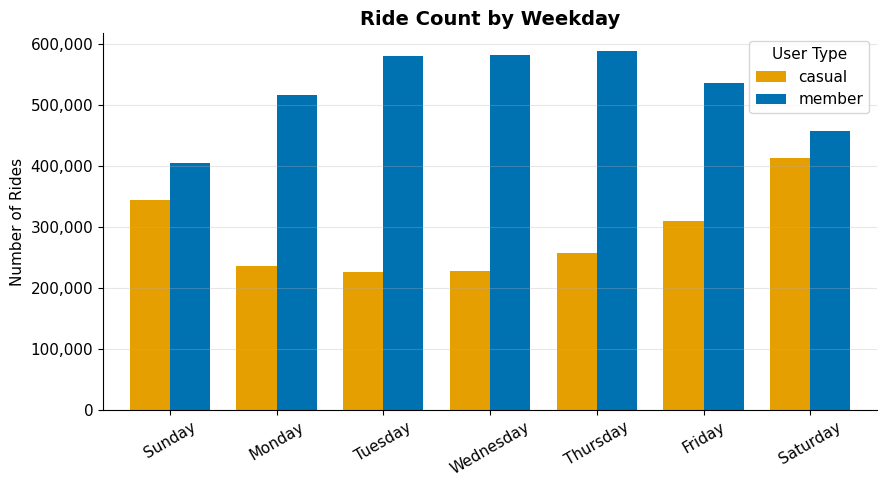

In [24]:
import matplotlib.pyplot as plt

weekday_plot = weekday.pivot(
    index="day_of_week",
    columns="member_casual",
    values="total_rides"
)

weekday_plot = weekday_plot.sort_index()
weekday_plot.index = [
    "Sunday",
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]
ax = weekday_plot.plot(
    kind="bar",
    figsize=(9,5),
    color=[CASUAL_COLOR, MEMBER_COLOR],
    width=0.75
)

ax.set_title("Ride Count by Weekday", fontsize=14, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Number of Rides")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="User Type")

from matplotlib.ticker import FuncFormatter

formatter = FuncFormatter(lambda x, pos: f"{int(x):,}")

ax.yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.show()

**Key Findings**
* Annual members generated more rides than casual riders on every day of the week, with the largest gap occurring on Thursday (588,302 vs. 256,650 rides).
* Member ridership remained relatively stable throughout weekdays (516k–588k rides/day), suggesting regular commuting behavior.
* Casual ridership peaked on Saturday (413,654 rides) and Sunday (344,408 rides), while weekday usage was substantially lower (225k–310k rides/day), indicating stronger recreational usage.


**Business Implication**
* The strong concentration of casual rides during weekends suggests that casual riders primarily use Cyclistic for leisure rather than daily commuting. Weekend-focused membership campaigns or benefits that encourage more frequent weekday use may increase the likelihood of converting casual riders into annual members.

# 5. Ride Count by Hour

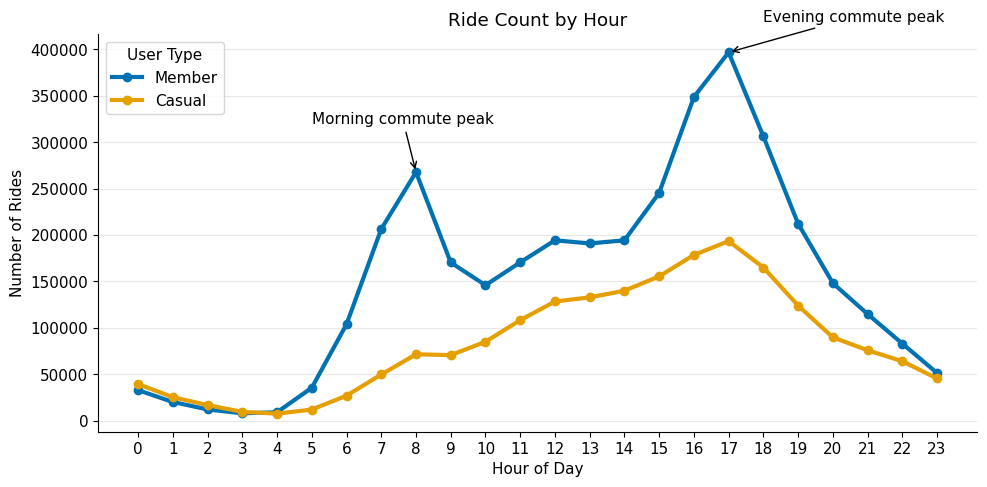

In [25]:
# Pivot data
hour_plot = hour.pivot(
    index="start_hour",
    columns="member_casual",
    values="total_rides"
)

hour_plot = hour_plot.sort_index()

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(
    hour_plot.index,
    hour_plot["member"],
    color=MEMBER_COLOR,
    linewidth=3,
    marker="o",
    label="Member"
)

ax.plot(
    hour_plot.index,
    hour_plot["casual"],
    color=CASUAL_COLOR,
    linewidth=3,
    marker="o",
    label="Casual"
)

ax.annotate(
    "Morning commute peak",
    xy=(8,267714),
    xytext=(5,320000),
    arrowprops=dict(arrowstyle="->")
)

ax.annotate(
    "Evening commute peak",
    xy=(17,396868),
    xytext=(18,430000),
    arrowprops=dict(arrowstyle="->")
)
ax.set_xticks(range(24))
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Rides")
ax.set_title("Ride Count by Hour")

ax.grid(axis="y", alpha=.3)

plt.legend(title="User Type")

plt.tight_layout()
plt.show()

**Key Findings**
* Member ridership shows two distinct commuting peaks, reaching 267,714 rides at 8:00 AM and 396,868 rides at 5:00 PM, indicating frequent use for commuting.
* Casual ridership increases gradually throughout the day and peaks at 193,362 rides at 5:00 PM, without a pronounced morning rush hour.
* Between 6:00 AM and 9:00 AM, member rides substantially exceed casual rides (e.g., 267,714 vs. 71,394 rides at 8:00 AM), suggesting that annual members rely on Cyclistic for regular weekday travel.
* After 10:00 AM, the gap between the two groups narrows as casual riders become more active, consistent with leisure or flexible-trip behavior.

**Business Implication**

* The pronounced morning and evening commuting peaks among members suggest that membership provides strong value for routine travel. Marketing campaigns targeting casual riders could emphasize the convenience and cost savings of annual membership for frequent weekday commuting, particularly during peak travel hours.

# 6. Ride Count by Month

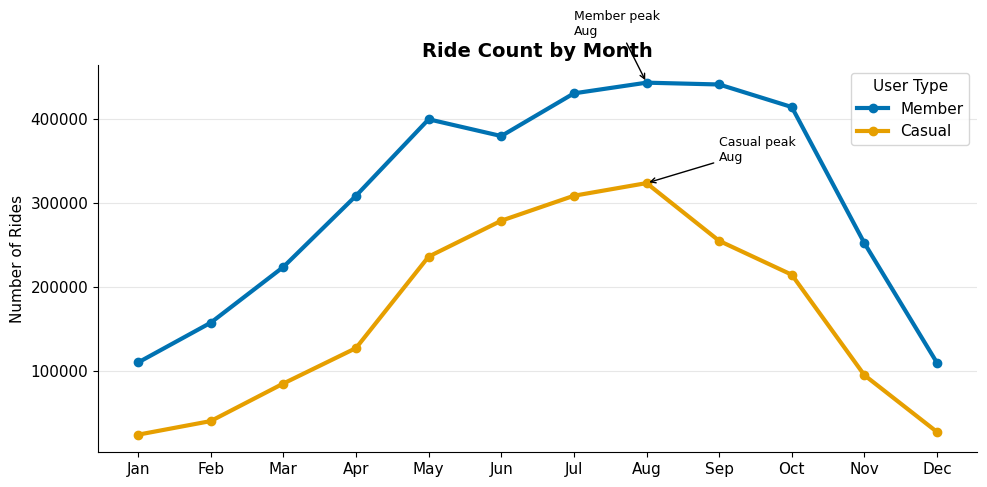

In [26]:
# Pivot data
month_plot = month.pivot(
    index="month",
    columns="member_casual",
    values="total_rides"
)

# Sort months
month_plot = month_plot.sort_index()

# Month labels
month_plot.index = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(
    month_plot.index,
    month_plot["member"],
    color=MEMBER_COLOR,
    linewidth=3,
    marker="o",
    label="Member"
)

ax.plot(
    month_plot.index,
    month_plot["casual"],
    color=CASUAL_COLOR,
    linewidth=3,
    marker="o",
    label="Casual"
)
# Peak month - Member
ax.annotate(
    "Member peak\nAug",
    xy=("Aug",443035),
    xytext=("Jul",500000),
    arrowprops=dict(arrowstyle="->"),
    fontsize=9
)

# Peak month - Casual
ax.annotate(
    "Casual peak\nAug",
    xy=("Aug",323448),
    xytext=("Sep",350000),
    arrowprops=dict(arrowstyle="->"),
    fontsize=9
)
ax.set_title("Ride Count by Month", fontsize=14, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Number of Rides")

ax.grid(axis="y", alpha=.3)

plt.legend(title="User Type")

plt.tight_layout()
plt.show()

**Key Findings**
* Both customer groups exhibited strong seasonality, with ride volume increasing steadily from spring and peaking in August (443,035 rides for members and 323,448 rides for casual riders).
* Member ridership remained consistently higher than casual ridership throughout the year, with the largest monthly gap observed during the summer months (e.g., 443,035 vs. 323,448 rides in August).
* Casual ridership showed greater seasonal fluctuation, increasing from 23,873 rides in January to 323,448 rides in August (more than 13× growth), whereas member ridership grew from 109,839 to 443,035 rides (approximately 4× growth).
* Ride demand for both groups declined sharply after October, reflecting the impact of colder weather on bike usage.

**Business Implication**
* Casual riders become substantially more active during the summer months, suggesting that warm-weather leisure trips create valuable opportunities for conversion. Cyclistic should launch seasonal membership campaigns before peak demand (e.g., April–June), encouraging frequent summer riders to switch to annual memberships before their riding activity reaches its highest level.

# 7. Average Ride Duration

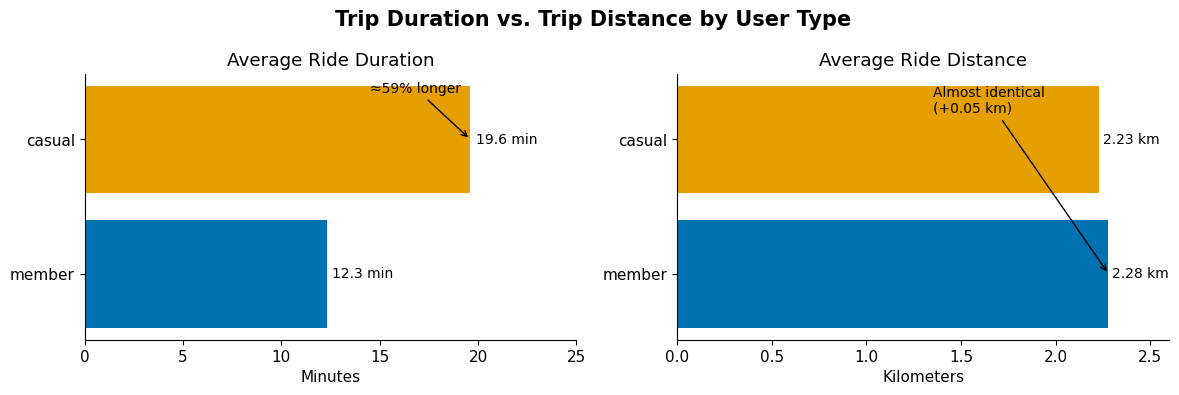

In [27]:
import matplotlib.pyplot as plt

# Consistent colors
COLORS = {
    "member": MEMBER_COLOR,
    "casual": CASUAL_COLOR
}

# Create two charts side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ===========================
# Chart 1: Average Ride Duration
# ===========================

bars1 = axes[0].barh(
    overall["member_casual"],
    overall["avg_ride_minutes"],
    color=[COLORS[x] for x in overall["member_casual"]]
)

for bar in bars1:
    width = bar.get_width()
    axes[0].text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f} min",
        va="center",
        fontsize=10
    )

axes[0].set_title("Average Ride Duration")
axes[0].set_xlabel("Minutes")
axes[0].set_ylabel("")
axes[0].set_xlim(0,25)

# Highlight difference
axes[0].annotate(
    "≈59% longer",
    xy=(19.6,1),
    xytext=(14.5,1.35),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10,
    color="black"
)

# ===========================
# Chart 2: Average Ride Distance
# ===========================

bars2 = axes[1].barh(
    overall["member_casual"],
    overall["avg_distance_km"],
    color=[COLORS[x] for x in overall["member_casual"]]
)

for bar in bars2:
    width = bar.get_width()
    axes[1].text(
        width + 0.02,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f} km",
        va="center",
        fontsize=10
    )

axes[1].set_title("Average Ride Distance")
axes[1].set_xlabel("Kilometers")
axes[1].set_ylabel("")
axes[1].set_xlim(0,2.6)

# Highlight similarity
axes[1].annotate(
    "Almost identical\n(+0.05 km)",
    xy=(2.28,0),
    xytext=(1.35,1.2),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# Overall title
fig.suptitle(
    "Trip Duration vs. Trip Distance by User Type",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

# Leave room for title
plt.subplots_adjust(top=0.82)

plt.show()

**Key Findings**
* Casual riders spent 19.6 minutes per trip, compared with 12.3 minutes for annual members—approximately 59% longer on average.
* Despite the longer trip duration, casual riders traveled an average of 2.23 km, which was nearly identical to the 2.28 km recorded by annual members (a difference of only 0.05 km).
* The contrast between substantially longer ride durations and nearly identical travel distances suggests that casual riders spend more time during each trip without covering significantly greater distances.

**Business Implication**
* The findings suggest that casual riders are more likely to use Cyclistic bikes for leisure or recreational trips rather than efficient point-to-point transportation. Marketing campaigns should therefore emphasize how an annual membership can enhance recreational riding through greater convenience and cost savings, while also encouraging more frequent use beyond occasional leisure trips.

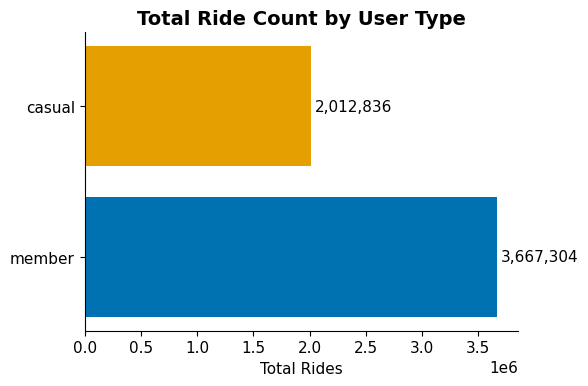

In [28]:
fig, ax = plt.subplots(figsize=(6,4))

bars = ax.barh(
    overall["member_casual"],
    overall["total_rides"],
    color=[COLORS[x] for x in overall["member_casual"]]
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 30000,
        bar.get_y() + bar.get_height()/2,
        f"{width:,.0f}",
        va="center"
    )

ax.set_xlabel("Total Rides")
ax.set_ylabel("")
ax.set_title("Total Ride Count by User Type", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

**Key Findings**
* Annual members completed 3.67 million rides, while casual riders completed 2.01 million rides.
* Members generated approximately 82% more rides than casual riders.
* The substantially higher ride frequency suggests that annual members rely on Cyclistic for regular transportation.

**Business Implication**
* Since annual members already ride much more frequently, marketing efforts should focus on encouraging casual riders to increase riding frequency rather than simply increasing trip duration. Demonstrating the long-term value of membership for riders who use the service repeatedly could help convert casual users into annual members.

| User   | Loop ride % |
| ------ | ----------: |
| Member |       2.59% |
| Casual |       7.20% |

**Key Findings**
* 7.2% of casual rides started and ended at the same station, compared with only 2.59% for annual members.
* Casual riders were nearly three times more likely to take loop trips than members.
* This pattern further supports the conclusion that casual riders use Cyclistic primarily for leisure or sightseeing rather than point-to-point transportation.

**Business Implication**
* Marketing messages for casual riders could emphasize the flexibility and cost-effectiveness of annual memberships for repeat leisure rides, especially during weekends and peak cycling seasons.

# 8. Bike Preference

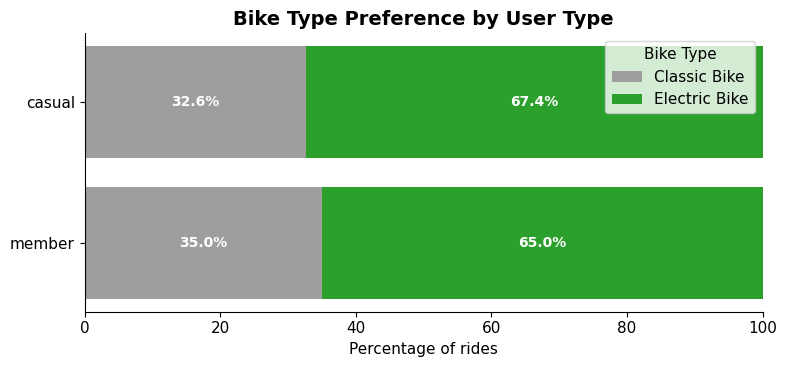

In [29]:
import matplotlib.pyplot as plt

# Pivot data
bike_plot = bike.pivot(
    index="member_casual",
    columns="rideable_type",
    values="pct_within_group"
)

# Reorder rows
bike_plot = bike_plot.loc[["member", "casual"]]

# Colors
bike_colors = {
    "classic_bike": "#9E9E9E",
    "electric_bike": "#2CA02C"
}

fig, ax = plt.subplots(figsize=(8,3.8))

left = [0,0]

for col in ["classic_bike","electric_bike"]:

    bars = ax.barh(
        bike_plot.index,
        bike_plot[col],
        left=left,
        color=bike_colors[col],
        label=col.replace("_"," ").title()
    )

    # labels inside bars
    for i, value in enumerate(bike_plot[col]):
        if value > 8:
            ax.text(
                left[i] + value/2,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=10,
                fontweight="bold"
            )

    left = [left[i] + bike_plot[col].iloc[i] for i in range(len(left))]

ax.set_xlim(0,100)

ax.set_xlabel("Percentage of rides")
ax.set_ylabel("")

ax.set_title(
    "Bike Type Preference by User Type",
    fontsize=14,
    fontweight="bold"
)

ax.legend(title="Bike Type")

plt.tight_layout()
plt.show()

**Key Findings**
* Electric bikes were the preferred option for both customer groups, accounting for 67.4% of casual rides and 65.0% of member rides.
* Classic bikes represented approximately one-third of rides for both groups (32.6% for casual riders and 35.0% for members).
* The difference in bike type preference between casual riders and annual members was minimal, indicating that both groups exhibit similar preferences when selecting bike types.

**Business Implication**
* Since casual riders and annual members demonstrate nearly identical bike type preferences, bike availability alone is unlikely to influence membership conversion. Marketing strategies should instead focus on behavioral differences—such as riding frequency, trip timing, and trip purpose—which showed much stronger distinctions throughout the analysis.

# 9. Top Start Stations

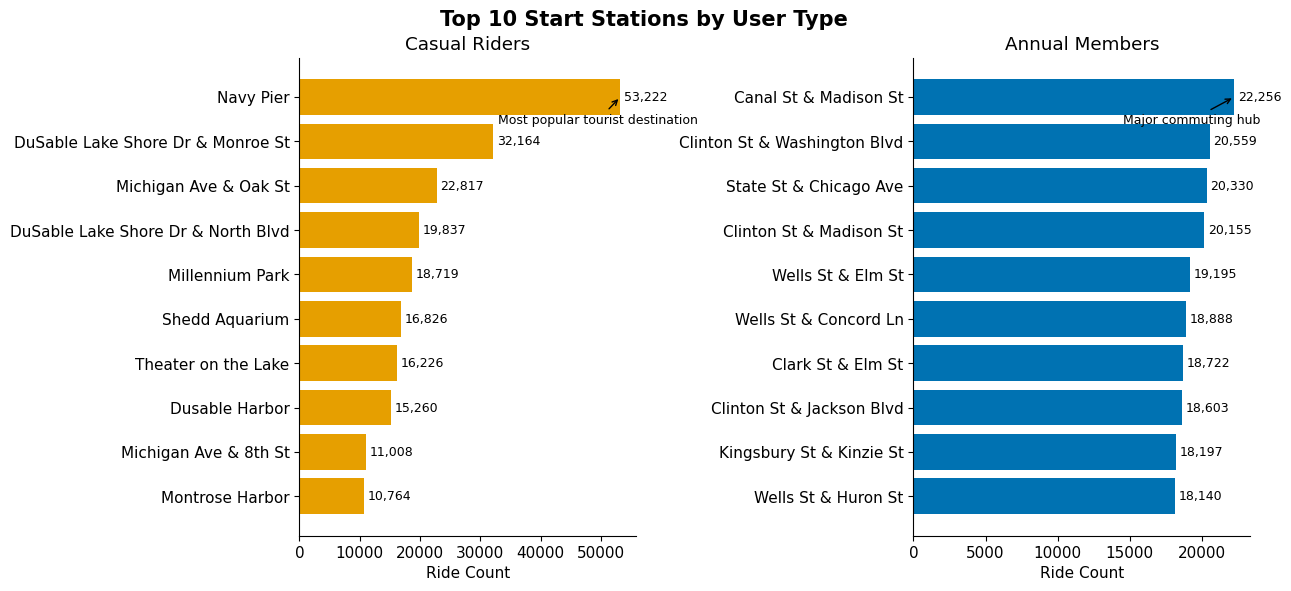

In [30]:
import matplotlib.pyplot as plt

# Split data
casual_station = (
    station[station["member_casual"]=="casual"]
    .sort_values("total_rides")
)

member_station = (
    station[station["member_casual"]=="member"]
    .sort_values("total_rides")
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13,6),
    sharex=False
)

# -----------------------------
# Casual
# -----------------------------

axes[0].barh(
    casual_station["start_station_name"],
    casual_station["total_rides"],
    color=CASUAL_COLOR
)

axes[0].set_title("Casual Riders")

axes[0].set_xlabel("Ride Count")

for i, value in enumerate(casual_station["total_rides"]):
    axes[0].text(
        value+600,
        i,
        f"{value:,}",
        va="center",
        fontsize=9
    )

# Highlight top station
axes[0].annotate(
    "Most popular tourist destination",
    xy=(53222,9),
    xytext=(33000,8.4),
    arrowprops=dict(arrowstyle="->"),
    fontsize=9
)

# -----------------------------
# Member
# -----------------------------

axes[1].barh(
    member_station["start_station_name"],
    member_station["total_rides"],
    color=MEMBER_COLOR
)

axes[1].set_title("Annual Members")

axes[1].set_xlabel("Ride Count")

for i, value in enumerate(member_station["total_rides"]):
    axes[1].text(
        value+250,
        i,
        f"{value:,}",
        va="center",
        fontsize=9
    )

axes[1].annotate(
    "Major commuting hub",
    xy=(22256,9),
    xytext=(14500,8.4),
    arrowprops=dict(arrowstyle="->"),
    fontsize=9
)

fig.suptitle(
    "Top 10 Start Stations by User Type",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.subplots_adjust(top=.90)

plt.show()

Key Findings
* Casual riders most frequently started their trips from Navy Pier (53,222 rides), followed by DuSable Lake Shore Drive & Monroe Street (32,164 rides) and Michigan Avenue & Oak Street (22,817 rides).
* Annual members most frequently started from Canal Street & Madison Street (22,256 rides), Clinton Street & Washington Boulevard (20,559 rides), and State Street & Chicago Avenue (20,330 rides).
* The two user groups showed almost no overlap in their top start stations. Casual riders were concentrated around waterfront and tourist destinations, whereas annual members primarily used stations located in downtown business and commuting areas.

**Business Implication**
* The distinct station preferences indicate that casual riders and annual members use Cyclistic bikes in different urban contexts. Marketing campaigns targeting casual riders should focus on high-traffic recreational locations such as Navy Pier and Millennium Park, where visitors are more likely to encounter the service. In contrast, operational planning and membership retention efforts should continue to prioritize stations serving daily commuters.

# Key Findings
* Usage Purpose: Annual members primarily use Cyclistic for commuting, with clear peaks during rush hours (8 AM and 5 PM). Casual riders, by contrast, ride mainly for leisure, showing a gradual increase throughout the day and peaking at 5 PM.

* Weekday vs. Weekend Patterns: Members maintain steady weekday usage (over half a million rides daily), while casual riders concentrate activity on weekends, especially Saturday and Sunday.

* Ride Duration vs. Distance: Casual riders spend significantly more time per trip (19.6 minutes vs. 12.3 minutes) but cover nearly the same distance, reflecting leisure-oriented behavior.

* Seasonality: Casual demand is highly seasonal, surging thirteenfold from January to August, whereas member demand grows more steadily (fourfold).

* Bike Type Preference: Both groups show similar preferences, with electric bikes accounting for about two-thirds of rides.

* Starting Locations: Casual riders begin trips at recreational and tourist hotspots, while members start near business districts and transit corridors, reinforcing the commuting versus leisure distinction.

# Business Recommendations

**Recommendation 1**
Launch targeted membership campaigns from April to June to engage highly active casual riders before peak summer demand.

Supporting findings
* Casual ridership begins increasing in April and reaches its highest level during July–September.
* August records the highest number of casual rides.

Possible marketing initiatives
* Limited-time membership discounts
* Free trial memberships
* Weekend membership bundles
* Referral incentives for first-time annual members

Expected business impact:
*Increase annual membership conversion before peak riding season while reducing reliance on single-ride purchases.*

**Recommendation 2**
Position annual membership as the best value for recreational riders

Supporting Findings
* Casual riders spend an average of 19.6 minutes per trip, compared with 12.3 minutes for annual members.
* Despite longer ride durations, both groups travel nearly the same average distance (2.23 km vs. 2.28 km).
* Casual riders also record a much higher proportion of loop trips (7.2% vs. 2.6%), suggesting greater recreational usage.

Possible Marketing Initiatives
* Highlight unlimited rides and cost savings in membership messaging.
* Position membership as the ideal option for riders who frequently enjoy recreational cycling.
* Develop campaigns emphasizing freedom, convenience, and flexibility, rather than distance traveled.
* Promote stories showing how regular leisure riders can save money by becoming members.

Expected Business Impact:
*Increase perceived value of annual membership among recreational riders. Encourage repeat leisure riders to transition from single rides to annual memberships.Strengthen membership adoption without relying solely on price-based promotions.*

**Recommendation 3**
Target high-traffic recreational locations for membership promotion

Supporting Findings
* Casual riders most frequently begin trips at popular recreational destinations, including Navy Pier, DuSable Lake Shore Drive, Millennium Park, and Shedd Aquarium.
* In contrast, annual members primarily start trips near business districts and commuter stations.

Possible Marketing Initiatives
* Install QR-code membership sign-up stations at major tourist attractions.
* Deploy digital signage promoting annual membership benefits.
* Offer location-based promotional discounts through the Cyclistic app.
* Partner with nearby attractions or local events to promote memberships during peak visitor periods.

Expected Business Impact:

*Increase visibility among high-potential casual riders.Improve campaign efficiency by focusing marketing resources where casual demand is highest.Generate higher conversion rates through location-based targeting.*


**Recommendation 4**
Promote annual membership as the preferred solution for everyday commuting

Supporting Findings
* Annual members exhibit clear riding peaks during weekday morning (7–9 AM) and evening (4–6 PM) commuting hours.
* Casual riders show stronger activity during afternoons and weekends, indicating more leisure-oriented travel.
* Member usage remains relatively consistent throughout the workweek, suggesting routine transportation behavior.

Possible Marketing Initiatives
* Develop commuter-focused membership campaigns emphasizing unlimited rides and predictable transportation costs.
* Partner with employers and universities to offer discounted memberships.
* Promote annual membership as an affordable alternative to driving or public transportation.
* Introduce new-member commuter incentives, such as discounted first-year memberships.

Expected Business Impact:
*Increase membership adoption among riders who commute regularly.Improve customer retention through habitual weekday usage.Expand Cyclistic's recurring membership revenue by attracting frequent transportation users.*
